# Chapter 2.4 — Multi-Product Series
### AFML by Marcos López de Prado
Real S&P 500 Futures Data · Sections 2.4.1, 2.4.2, 2.4.3

This notebook demonstrates three techniques for working with multiple futures contracts:
- **Section 2.4.1** — ETF Trick: combine multiple instruments into a single $1 portfolio value series
- **Section 2.4.2** — PCA Weights: find risk-balanced portfolio allocations using spectral decomposition
- **Section 2.4.3** — Single Future Roll: remove artificial price gaps when contracts expire and roll

## Setup — Imports and Data Loading

In [ ]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multi_product as mp

print("Imports successful.")

Imports successful.


### Load S&P 500 Futures Contracts

Each contract covers one quarterly period. Contract names follow the convention:
- `SP` = S&P 500 futures
- `98` = year 1998
- `H/M/U/Z` = expiry month (March / June / September / December)

In [ ]:
base = os.path.abspath('.')

def load_contract(filename):
    path = os.path.join(base, 'input_data', filename)
    first = pd.read_csv(path, nrows=1, header=None)
    has_header = not str(first.iloc[0, 0]).isdigit()
    if has_header:
        df = pd.read_csv(path)
        df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt']
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        df = pd.read_csv(path, header=None,
                         names=['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt'])
        df['Date'] = pd.to_datetime(df['Date'], format='%y%m%d')
    return df

sp98h = load_contract('SP98H.txt')
sp98m = load_contract('SP98M.txt')
sp98u = load_contract('SP98U.txt')
print("Contracts loaded.")

Contracts loaded.


### Align Dates and Build DataFrames

We keep only dates where all three contracts have data, so our DataFrames are the same length.

In [ ]:
dates = sp98h['Date']
common_dates = dates[dates.isin(sp98m['Date']) & dates.isin(sp98u['Date'])]

sp98h_aligned = sp98h[sp98h['Date'].isin(common_dates)].set_index('Date')
sp98m_aligned = sp98m[sp98m['Date'].isin(common_dates)].set_index('Date')
sp98u_aligned = sp98u[sp98u['Date'].isin(common_dates)].set_index('Date')

instruments = ['SP98H', 'SP98M', 'SP98U']

close_prices = pd.DataFrame({
    'SP98H': sp98h_aligned['Close'],
    'SP98M': sp98m_aligned['Close'],
    'SP98U': sp98u_aligned['Close']
}).dropna()

open_prices = pd.DataFrame({
    'SP98H': sp98h_aligned['Open'],
    'SP98M': sp98m_aligned['Open'],
    'SP98U': sp98u_aligned['Open']
}).dropna()

volumes = pd.DataFrame({
    'SP98H': sp98h_aligned['Volume'],
    'SP98M': sp98m_aligned['Volume'],
    'SP98U': sp98u_aligned['Volume']
}).dropna()

common_idx = close_prices.index
common_idx = common_idx[common_idx >= '1998-01-01']
close_prices = close_prices.loc[common_idx]
open_prices  = open_prices.loc[common_idx]
volumes      = volumes.loc[common_idx]
n_bars       = len(close_prices)

print(f"Common bars across all 3 contracts: {n_bars}")
print(f"Date range: {common_idx[0].date()} to {common_idx[-1].date()}")
close_prices.head()

Common bars across all 3 contracts: 53
Date range: 1998-01-02 to 1998-03-19


,SP98H,SP98M,SP98U
Date,,,
1998-01-02,984.7,994.9,1005.0
1998-01-05,986.9,997.0,1007.1
1998-01-06,971.0,981.0,990.9
1998-01-07,974.0,984.0,994.0
1998-01-08,961.2,971.0,980.6


### Portfolio Parameters

We set up equal weights, point values, dividends, transaction costs and rebalance dates.

In [ ]:
point_values = pd.DataFrame(
    np.ones((n_bars, 3)) * 250,
    index=common_idx, columns=instruments
)

dividends = pd.DataFrame(
    np.zeros((n_bars, 3)),
    index=common_idx, columns=instruments
)

alloc_weights = pd.DataFrame(
    np.ones((n_bars, 3)) / 3,
    index=common_idx, columns=instruments
)

trans_costs     = pd.Series(1e-4, index=instruments)
rebalance_dates = list(common_idx[::63])

print(f"Rebalancing every 63 bars (~quarterly). Total rebalance dates: {len(rebalance_dates)}")

Rebalancing every 63 bars (~quarterly). Total rebalance dates: 1


## Section 2.4.2 — PCA Weights

PCA weights find the underlying market factors driving price movement across instruments,
then allocate risk equally across those factors.

For three highly correlated S&P 500 contracts, most risk comes from one factor —
the broad market direction. Equal risk allocation forces large offsetting positions
to extract meaningful exposure from the near-zero spread component.

In [ ]:
returns   = close_prices.pct_change().dropna()
cov       = returns.cov().values
risk_dist = np.ones(3) / 3
weights   = mp.pca_weights(cov, risk_dist=risk_dist, risk_target=1.0)

print("PCA Weights:")
for i, w in zip(instruments, weights.flatten()):
    print(f"  {i}: {w:+.4f}  ({'LONG' if w > 0 else 'SHORT'})")

PCA Weights:
  SP98H: -2767.8244  (SHORT)
  SP98M: +11027.4932  (LONG)
  SP98U: -8261.1638  (SHORT)


### PCA Weights Chart

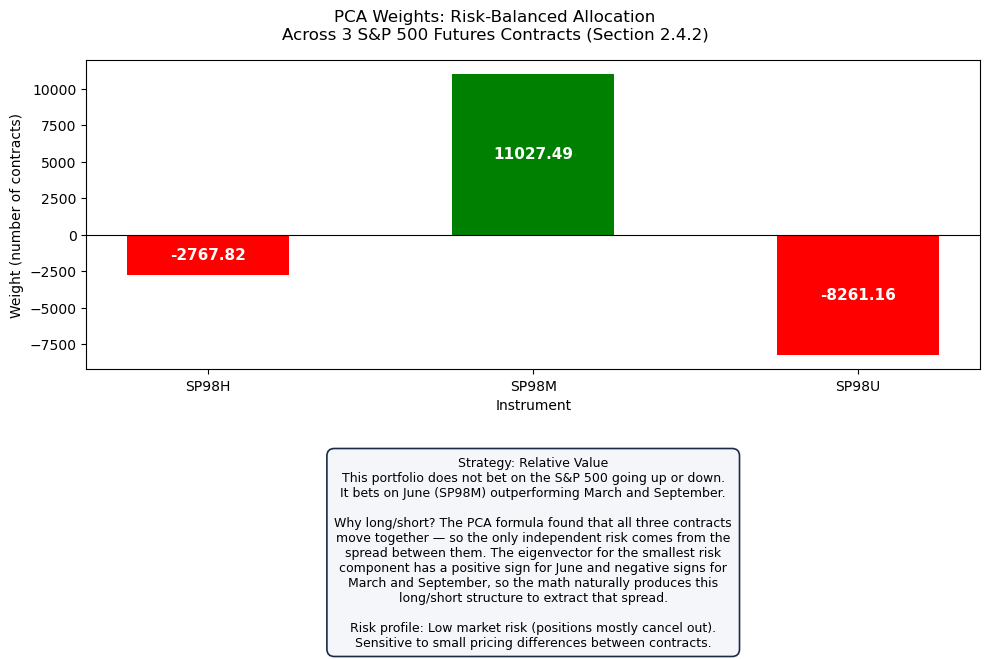

In [ ]:
weight_values = weights.flatten()
colors = ['green' if w > 0 else 'red' for w in weight_values]

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("PCA Weights: Risk-Balanced Allocation\nAcross 3 S&P 500 Futures Contracts (Section 2.4.2)",
             fontsize=12)
ax.bar(instruments, weight_values, color=colors, width=0.5)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel("Instrument")
ax.set_ylabel("Weight (number of contracts)")

for i, w in enumerate(weight_values):
    if abs(w) > 500:
        ax.text(i, w / 2, f'{w:.2f}', ha='center', va='center',
                fontsize=11, color='white', fontweight='bold')
    else:
        offset = 200 if w >= 0 else -400
        ax.text(i, w + offset, f'{w:.2f}', ha='center', va='center',
                fontsize=11, color='black', fontweight='bold')

explanation = (
    "Strategy: Relative Value\n"
    "This portfolio does not bet on the S&P 500 going up or down.\n"
    "It bets on June (SP98M) outperforming March and September.\n\n"
    "Why long/short? The PCA formula found that all three contracts\n"
    "move together — so the only independent risk comes from the\n"
    "spread between them. The eigenvector for the smallest risk\n"
    "component has a positive sign for June and negative signs for\n"
    "March and September, so the math naturally produces this\n"
    "long/short structure to extract that spread.\n\n"
    "Risk profile: Low market risk (positions mostly cancel out).\n"
    "Sensitive to small pricing differences between contracts."
)
ax.text(0.5, -0.28, explanation, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='center',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#F4F6FA', edgecolor='#1B2A4A', linewidth=1.2))

plt.tight_layout()
plt.subplots_adjust(bottom=0.38)
plt.show()

## Section 2.4.1 — ETF Trick

The ETF Trick combines multiple instruments into a single continuous $1 investment series K_t.
It solves three problems with naive price stitching: different units, roll gaps, and negative prices.

In [ ]:
result = mp.etf_trick(
    open_prices     = open_prices,
    close_prices    = close_prices,
    alloc_weights   = alloc_weights,
    point_values    = point_values,
    dividends       = dividends,
    rebalance_dates = rebalance_dates,
    trans_costs     = trans_costs,
    volumes         = volumes
)

print("ETF Trick output (first 10 rows):")
result.head(10)

ETF Trick output (first 10 rows):


,K,rebalance_cost,bid_ask_cost,volume
Date,,,,
1998-01-02,1.000000,0.0000,0.000000,0.0
1998-01-05,1.000000,0.0001,0.000000,0.0
1998-01-06,0.983913,0.0000,0.000098,191852550.0
1998-01-07,0.986957,0.0000,0.000099,12840525.0
1998-01-08,0.973848,0.0000,0.000097,59670675.0
1998-01-09,0.941277,0.0000,0.000094,319502475.0
1998-01-12,0.957696,0.0000,0.000096,197139825.0
1998-01-13,0.971910,0.0000,0.000097,109522125.0
1998-01-14,0.975789,0.0000,0.000098,133692525.0


### Output Notes

| Column | Description |
|--------|-------------|
| **K** | Portfolio value starting at $1. Rises and falls with daily P&L across all three contracts. |
| **rebalance_cost** | Transaction cost paid on rebalance days only (~every 63 bars). Zero on all other days. |
| **bid_ask_cost** | Implicit spread cost of holding positions, computed every bar. Small (~0.0001) because S&P 500 futures are highly liquid. |
| **volume** | How many ETF units could be traded today, limited by the least liquid instrument. Large values reflect that our $1 portfolio is tiny relative to market liquidity. |

### ETF Trick Chart — Portfolio Value Over Time

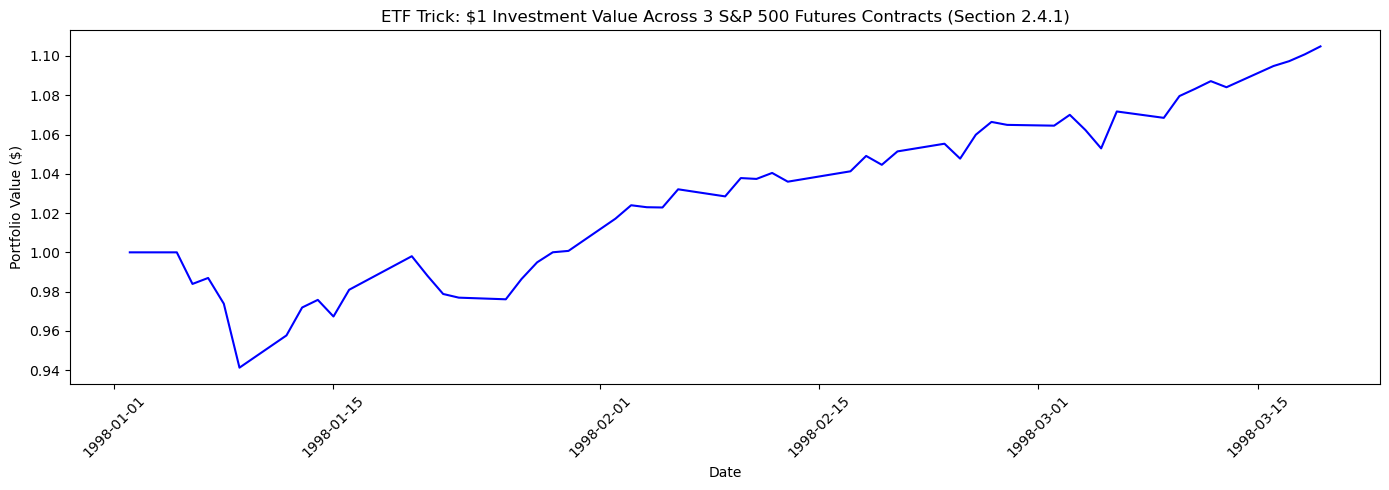

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(result.index, result['K'], color='blue')
ax.set_title("ETF Trick: $1 Investment Value Across 3 S&P 500 Futures Contracts (Section 2.4.1)")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Section 2.4.3 — Single Future Roll

When a futures contract expires, the new contract trades at a slightly different price.
Naively stitching contracts together creates artificial price jumps.

**Roll Gaps** removes these jumps by adding a fixed dollar adjustment to historical prices.
**rPrices** does the same using ratios instead — guaranteeing the series can never go negative.

In [ ]:
front_month_contracts = [
    ('SP98H', '1998-01-01', '1998-03-20'),
    ('SP98M', '1998-03-21', '1998-06-19'),
    ('SP98U', '1998-06-20', '1998-09-18'),
    ('SP98Z', '1998-09-19', '1998-12-18'),
    ('SP99H', '1998-12-19', '1999-03-19'),
    ('SP99M', '1999-03-20', '1999-06-18'),
    ('SP99U', '1999-06-19', '1999-09-17'),
    ('SP99Z', '1999-09-18', '1999-12-17'),
    ('SP00H', '1999-12-18', '2000-03-16'),
    ('SP00M', '2000-03-17', '2000-06-15'),
    ('SP00U', '2000-06-16', '2000-09-14'),
    ('SP00Z', '2000-09-15', '2000-12-14'),
]

pieces = []
for contract, start, end in front_month_contracts:
    df = load_contract(f'{contract}.txt')
    df = df[(df['Date'] >= start) & (df['Date'] <= end)].copy()
    df['Instrument'] = contract
    pieces.append(df)

futures_series = pd.concat(pieces).sort_values('Date').reset_index(drop=True)
futures_series = futures_series.set_index('Date')

print(f"Stitched futures series: {len(futures_series)} bars")
print(f"Date range: {futures_series.index[0].date()} to {futures_series.index[-1].date()}")
print(f"Contracts used: {futures_series['Instrument'].unique().tolist()}")

Stitched futures series: 738 bars
Date range: 1998-01-02 to 2000-12-14
Contracts used: ['SP98H', 'SP98M', 'SP98U', 'SP98Z', 'SP99H', 'SP99M', 'SP99U', 'SP99Z', 'SP00H', 'SP00M', 'SP00U', 'SP00Z']


### Apply Roll Gap Correction

In [ ]:
dictio = {'Instrument': 'Instrument', 'Open': 'Open', 'Close': 'Close'}

rolled  = mp.get_rolled_series(futures_series, dictio=dictio, match_end=True)
non_neg = mp.non_negative_rolled_prices(futures_series, dictio=dictio, match_end=True)

print("Rolled series (first 10 rows):")
display(rolled[['Open', 'Close', 'Volume', 'Instrument']].head(10))

print("\nNon-negative rolled prices (first 10 rows):")
display(non_neg[['Close', 'Returns', 'rPrices']].head(10))

Rolled series (first 10 rows):


,Open,Close,Volume,Instrument
Date,,,,
1998-01-02,1143.2,1144.9,52852,SP98H
1998-01-05,1146.7,1147.1,96191,SP98H
1998-01-06,1140.2,1131.2,103105,SP98H
1998-01-07,1129.7,1134.2,116660,SP98H
1998-01-08,1129.2,1121.4,111356,SP98H
1998-01-09,1121.2,1089.7,141831,SP98H
1998-01-12,1079.2,1105.7,153844,SP98H
1998-01-13,1111.2,1119.7,113976,SP98H
1998-01-14,1122.7,1123.5,110552,SP98H



Non-negative rolled prices (first 10 rows):


,Close,Returns,rPrices
Date,,,
1998-01-02,1144.9,NaN,NaN
1998-01-05,1147.1,0.002234,1.002234
1998-01-06,1131.2,-0.016111,0.986087
1998-01-07,1134.2,0.003090,0.989134
1998-01-08,1121.4,-0.013142,0.976135
1998-01-09,1089.7,-0.032980,0.943942
1998-01-12,1105.7,0.017214,0.960191
1998-01-13,1119.7,0.014807,0.974408
1998-01-14,1123.5,0.003960,0.978267


### Roll Gap Charts

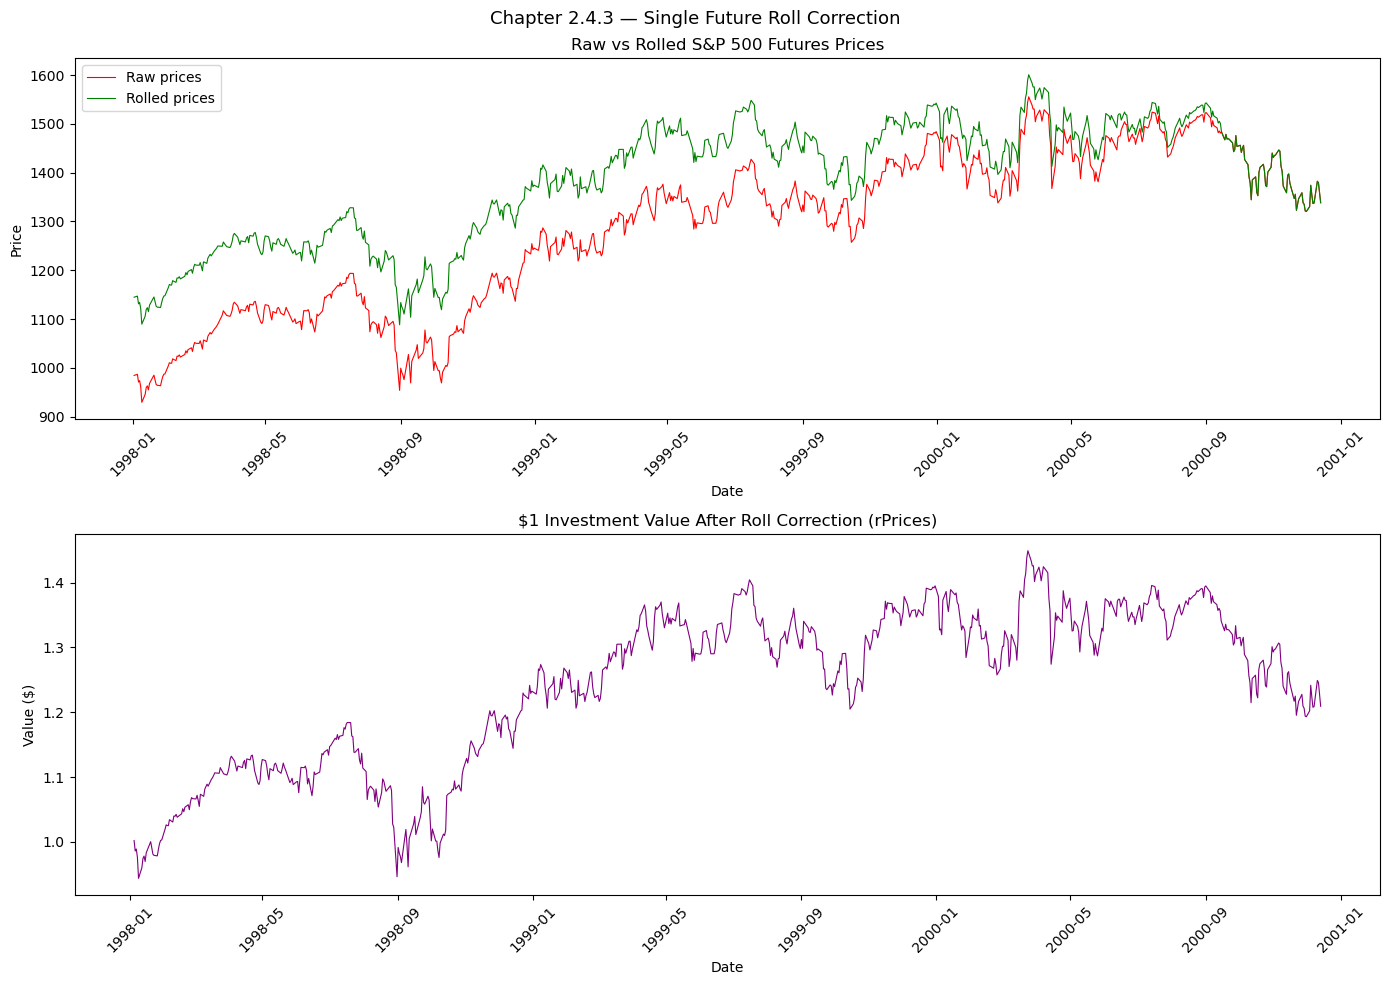

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Chapter 2.4.3 — Single Future Roll Correction", fontsize=13)

# Panel 1 — Raw vs rolled
axes[0].plot(futures_series.index, futures_series['Close'],
             color='red', label='Raw prices', linewidth=0.8)
axes[0].plot(rolled.index, rolled['Close'],
             color='green', label='Rolled prices', linewidth=0.8)
axes[0].set_title("Raw vs Rolled S&P 500 Futures Prices")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price")
axes[0].legend(loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

# Panel 2 — rPrices
axes[1].plot(non_neg.index, non_neg['rPrices'], color='purple', linewidth=0.8)
axes[1].set_title("$1 Investment Value After Roll Correction (rPrices)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value ($)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()